# How to Choose One Card By Analyzing Every Draft Ever


Welcome to my new platform dedicated to limited analytics! 
I'll just come out and say what I truly believe: If you read this article and listen to my advice, I'm going to pick you up a percent or more of win rate. I've got a lot of work to back up that claim, so I'll cut the preamble short. We're going to take a serious look at answering the question "How should I draft" using techniques that have not been attempted before, and with a wider scope than any previous analysis.

Ok, sorry, let me try again: we're going to look at answering the question "How should I pick my first card", and we're going deep. The rest of the draft is up to you, but pack one, pick one, that's a pick order. We rank the cards and pick the one that's highest in our list. We don't *have* to do that, but it works well enough. Recent years have seen the rise of GIH WR as the default objective reference for card rankings, but I don't think anyone has attempted to seriously answer the question "what happens when I take the highest GIH WR card from pack one and go from there," or to deeply compare the effects of relying on different metrics to make card choices. We're going to do that now, and more.

The way we're going to do that is conceptually simple and computationally somewhat complex. The simplest (relevant) thing to do is to just, well, look at when people took the highest GIH WR card and see what happened. For example, Sierko [took at a look at player behavior](https://www.youtube.com/watch?v=s9whxgw6wbU) around the GP WR metric in Foundations recently, including the question of what happens when people pick the highest ranked card and what happens when they don't. They do better when they do. The problem with drawing conclusions from that analysis is that 
the most valuable decisions we make are often the easiest. No one is having trouble slamming Sire of Seven Deaths P1P1, so those results, along with every other clear bomb, are going to fall into the "yes, you took the good card" bucket and skew the results. Given the major impact on the very best bombs on win rate, I think we should handle variation in opening luck carefully before drawing conclusions.

We could look at trying to adjust for opening luck using some kind of factor, but that's confounded by exactly the thing were trying to measure, so here's my solution: we need to know what happens when we take the highest ranked card from *every* pack using actual match results, not just the ones that were observed to be taken. For every draft, we'll identify the highest ranked card according to some metric, then go find a draft where that card was taken first, and swap out the results. Actually, we'll take all of the representative drafts and average the results. And while we're at it, we'll look at all the sets instead of just one. And all the metrics instead of just one. And for players of every skill level instead of just the average. There will be more technical details to discuss later, but this is the essence of the analysis.

Now, when we make this swap, we want the results to be as representative as possible to results that would have been obtained in the counterfactual. That is, ideally, the same player, on the same day. We might even ask for the card picked to be itself highest ranked, to simulate the concept of the strategy and not just the card picked, or for the distribution of alternatives to be similar, if we're feeling really greedy. Obviously we can't get that using real data, but I'll address each of these points briefly before we get to the results.

First, the player. Player skill is obviously an important driver of results beyond pick one, so it will be necessary to control for the variable. Otherwise we could just be observing more informed players making characteristic choices and winning due to their skill, rather than the effect of the choice itself. [17Lands](https://www.17lands.com/public_datasets) provides us with two invaluable but coarse data points pertaining to player skill, in the form of a "WR Bucket" data point, with intervals of 2%, measuring the players win rate over the set in question, and an "N Games" data point, counting the games played by that player. I used Bayesian inference to combine those two values to produce an estimate of player skill by regressing the win rate bucket variable back to the mean of 54% according to the number of games played. Then I truncated the results at 42% and 66% and combined the extreme outliers into those buckets. For details on the exact methodology see [this post](bayes-cohorts). I call the resulting value the "Skill Cohort"

So suppose your favorite streamer is an elite drafter who regularly posts a 64% win rate and plays over 500 games per set. Probably they will end up in the 62% bucket for each set. Only absolute maniacs are getting assigned to the 66% bucket, but there is generally one or two to be found per set. There are interesting things to look at even for this small sample size, but we shouldn't necessarily consider the results on the analysis conclusive out on the fringes. We'll take a close look at sample sizes later. In any case, I would consider anything north of 60 "elite". Now, I think having a representative player make the substitute choice is essential to the analysis, so rather than just making an adjustment for skill, I will attempt to enforce that a substitute draft is found within the same cohort as the opened pack. Depending on sample size and the weirdness of the suggestion (something we will measure and look at below), there may not be an example within the same skill cohort, in which case we go looking in neighboring cohorts, and this time we do attempt to adjust for skill (by adjusting the observed win rate appropriately). If nobody can be found making the pick in question within three neighboring cohorts, we assume the pick is providing no value, and use the cohorts baseline win rate adjusted downward by the estimated value of a first pick, for which I used 2.5%. All this adjusting is necessary to get something usable at every point on the curve, but the most significant results are derived purely from the one-for-one substitution within the player cohort, or with de minimus adjustments on the boundaries.

The other elements of proximity I mentioned I did not adjust for in the final analysis, but I did look at them. In general, the most effective metrics pushed the average date of the observed draft later in the data set, when more people were making better evaluations. I don't think it's probable that the results obtained from that are somehow exploiting the metagame in a way that would invalidate then, if we're seeking to explain away a modeled increase in win rate. If anything, I think that kind of result is probably attenuated from what would have been realized by being ahead of the curve. 

Next, the idea of replacing drafts only with drafts where the card in question was picked *as* the highest-ranked card in the pack was my original strategy. It added noise to the result, tripled the compute time, and it turns out it would wrong to do it that way, so I cleaned it up. See, there's a subtle potential source of bias where any skill attributable to *knowing* that a particular strategy is useful will tend to be cancelled out by a deficit in some other skill within a given skill bucket. We hope to not include anyone like that in our substitution analysis, because by swapping over to those drafts we get the skill deficit effect coupled with the quality boost. It's another reason to suppose that our final estimates might be biased towards a null result. We could hope for additional bias corrections for the contents of a pack, or rank, or anything else we can think of. I'm not too concerned that anything remaining would have a material result, but there's always room for more advanced techniques down the road.

Let's get to the results. The metrics I looked at were GIH WR, GP WR, ATA, and IWD. I took a brief look at OH WR as well, but the picks were really poorly represented by player behavior, so I don't think there's anything to see there. 

...


Ok, I'm not fooling anyone, I threw [DEq](https://docs.google.com/spreadsheets/d/1n1pfrb5q_2ICYk-vfF3Uwo8t61DJU-5T_DFe0dwk8DY/edit?usp=sharing) in the mix as well -- obviously, proving that my pet metric is the best is the whole point of this exercise. If you want to dive into the reasoning behind DEq, I wrote up a [derivation of the formula](deq) just for you. Really, literally, just for you, the one person who wants to wade through a needless pile of conditional probabilities. If you don't want to get sidetracked, DEq is basically GP WR plus "pick equity", a decreasing function of ATA that adds more value to highly picked cards.

## Results of the Substitution Analysis

I took five metrics, and public data for 16 major releases going back to NEO covering almost 2.27 million drafts. So no, not every draft ever, just the ones with a large enough collection of drafts and the necessary data points (particularly the skill cohort fields, which are missing from data before NEO). I divided each format into an "early" stage, covering prerelease and the first 12 days proper, and a "late" stage, chosen to split the corpus roughly in half. For the first cut, I calculated the metrics using the late format and an in-sample analogue of "Top" players, then applied the results to the entire set of drafts, set-by-set and metric-by-metric. One point I haven't mentioned is the event length weighting. Since the number of games you play is a function of win rate, for each pick pointed out by the metric, I weight the result by the number of drafts where that pick is pointed out times the average event length of events measured in the substitution set. Therefore, each metric has a slightly different total weight for each set, which we expect to closely track the real number of matches observed. We'll take a look at the total weights theough the lens of
entropy below. For each set, for each cohort, I documented the win rate resulting from the procedure described above, and plot the delta between the simulated metric strategy and the actual observed win rate by cohort. Time to present the results. I'm presenting this as an executable notebook. If you want to try this yourself, you'll need to clone and install my [deq repository](https://github.com/oelarnes/deq) and the ["spells-mtg"](https://github.com/oelarnes/spells) python package and be prepared to put your CPU in the oven for several hours.

In [1]:
# Imports and some definitions you might want to look at
# See (https://github.com/oelarnes/spells) for the function of the below line, which will download files to your computer
# !spells add all
from spells import summon, ColName

from deq.plot import p1strat_line_plot, set_by_set_plot
from deq.p1_strategy import all_metrics_analysis, SETS
import matplotlib.pyplot as plt

TOP_FILTER = {ColName.PLAYER_COHORT: 'Top'}
LATE_FORMAT = {'lhs': ColName.FORMAT_DAY, 'op': '>=', 'rhs': 13}
EARLY_FORMAT = {'$not': LATE_FORMAT}
LATE_TOP = {'$and': [TOP_FILTER, LATE_FORMAT]}
EARLY_TOP = {'$and': [TOP_FILTER, EARLY_FORMAT]}

print(f"Analyzed sets: {SETS}")
print(f"""Total number of drafts observed: {summon(
    SETS,
    columns=[ColName.NUM_DRAFTS], 
    group_by=[]
)['num_drafts'][0]}""")


Analyzed sets: ['DSK', 'FDN', 'MKM', 'SNC', 'MH3', 'WOE', 'LTR', 'DMU', 'NEO', 'BLB', 'KTK', 'MOM', 'ONE', 'BRO', 'OTJ', 'LCI']
Total number of drafts observed: 2269905


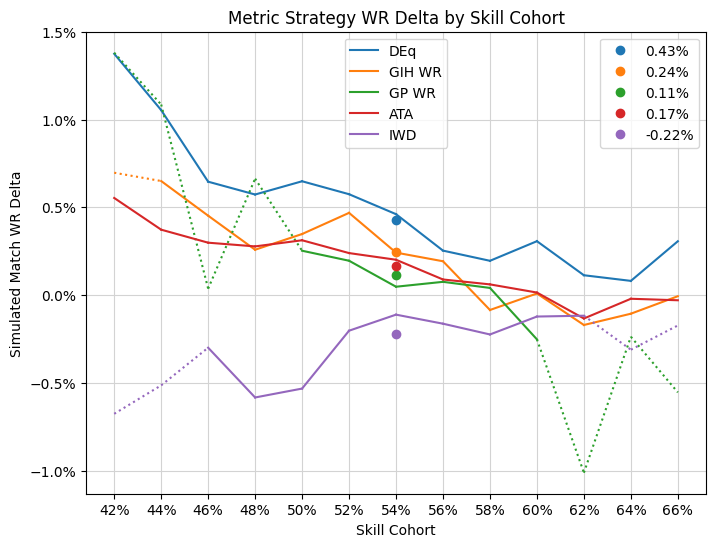

In [2]:
res_all = all_metrics_analysis(
    metric_filter=LATE_TOP
)
_ = p1strat_line_plot(res_all, mode='wr_delta')
plt.show()

The dots aligned above the 54% cohort represent the average increase in winrate aggregated across all of the cohorts. By picking the highest card in each pack one, as ranked by DEq (as calculated over the late format, top player metagame), in each draft, over 2.27 million drafts, the model estimates a 0.43% increase in win rate. Keep in mind, this is the result of *one* single choice made differently. In practice, you get to think about DEq for as many picks as you want to, and you get to (actually are compelled to by the laws of thermodynamics, we'll get to that) use a version more closely aligned to the present metagame. I think it's reasonable to guess that there are a couple percentage points of win rate at play here for a huge majority of players, just by taking card quality estimation seriously. From my own experience, the process of being in tune with card quality from day two pays greater dividends as a learning mechanism as well, so any external benefits of having a good estimate at your fingertips would be on top of the base effect of playing better cards. Furthermore, the result, *independently*, applies to each of the cohorts at least up to the 60% cohort, capturing a large majority of the most competitive, if not elite drafters
. Furthermore, it is the only metric to deliver clearly net positive results for any of the 58% and above cohorts.

## Entropy
Before we pull serious conclusions from this graph we have to talk about the dotted lines. This is going to seem potentially technical, but I'll avoid formulas and stick to the intuition behind the analysis. I believe this information is just as important as the win rate graph and you'll want to stick around, at least for a couple more charts. 

I mentioned that I was keeping track of the "weirdness" of the suggestions of each measure. When the substitution analysis replaces drafts, it creates a new weighted sample space that win rates are inferred from. I'm interested in tracking how the information from the original sample space is preserved under the transformation. There are a few ways that information is lost. First, it can just be thrown out. If cards are taken that are never highest ranked, then those observations are thrown out entirely. That won't happen often, but if the rate at which cards are suggested are very different from the rate they are taken, then some subsets of the metric will be inflated in importance within the new space, and their small number of samples will impact the information characteristics of the new space. The samples that made up disfavored picks will shrink in importance, and even though the total number of elements is similar, the information space is degraded, in terms of how the elements contribute to the expectation of variables. The sample size begins to more resemble the collection of inflated elements rather than the entire space.

Now, it may seem daunting to try to measure the effect of all of these relative changes to weight (it did to me anyway), but there's a standard way to represent this loss of information: entropy. In the context of a "measure", or synthetic
sample space, the entropy measures the effective "number of configurations" in logarithmic space, but with the nuance required to handle the situation discribed above. When we say "configuration", in this case we just mean a particular game we observe to estimate win rates.

Entropy, as presented here, is measured in "bits", so a value of 20 represents a sample space with 2^20 or about a million observations. Going down by one represents a loss of half the sample space. Each cohort has a different number of total match observations associated with it, and to obtain a win rate, by default, we weight evenly, which produces the theoretical maximum entropy. For each cohort, for each metric, the reweighting will produce a different amount of entropy attributable to the observations within the representative cohort, which will necessarily be lower than the base entropy. Therefore the difference from the total entropy to metric strategy's value is interpreted as the number of compounding halves of information lost. For example, if the difference is -3, only one eighth of the information is preserved, which is an arbitrary threshold we'll use to designate the endpoints of solid segments in our plots.

Now, since we go looking in neighboring cohorts for substitute data, some of the entropy in the final measure is attributable to that data. I'm interested in how the information from the representative data is retained, so I'll discard entropy from other sources, and consider only what I call the "Representative Entropy", which is sourced from the same skill cohort we are measuring.

Let's see the entropy plot and discuss its interpretation.

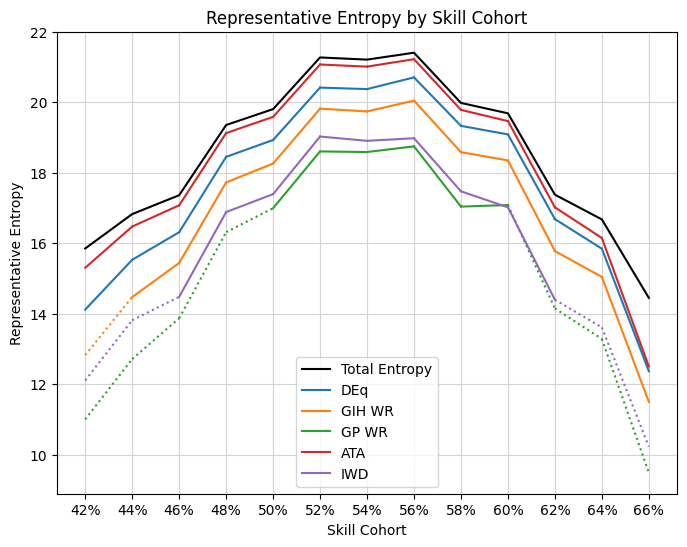

In [3]:
_ = p1strat_line_plot(
    res_all,
    mode='entropy'
)
plt.show()

This graph contains information about the total sample size for each cohort, as well as how each metric affects the information space. 
First check out the 54% cohort. The "total" entropy is about 21.2, which represents $2^{21.2}$ 
or about 2.4 
million games, which is indeed the number observed
for that cohort. For the 66% cohort, the value is a bit above 14, which corresponds to about 22,000 matches. Looking at the curves for the metric strategies
, the first thing to note is that the general shape matches what we should 
expect -- they generally reproduce the underlying sample space, so they should have the same order of magnitude of information, but 
with some degradation. This is a nice sanity check that we're doing something sensible with both the reweighting and the entropy calculation. Notably the elements that constitute the model entropy can have either positive or negative sign depending on the direction of scale, so the strict inequality is enforced only by the theoretical relationship, which is a cool effect to observe.

Now lets look at some of the particular curves. In order to do that it will be more convenient to set the total as a baseline and see how much of that entropy is lost in the transformation. So the next graph simply subtracts off the "total" line. The overall sample size is important, but I'm mostly interested in how the metric strategies reflect the underlying behavior.

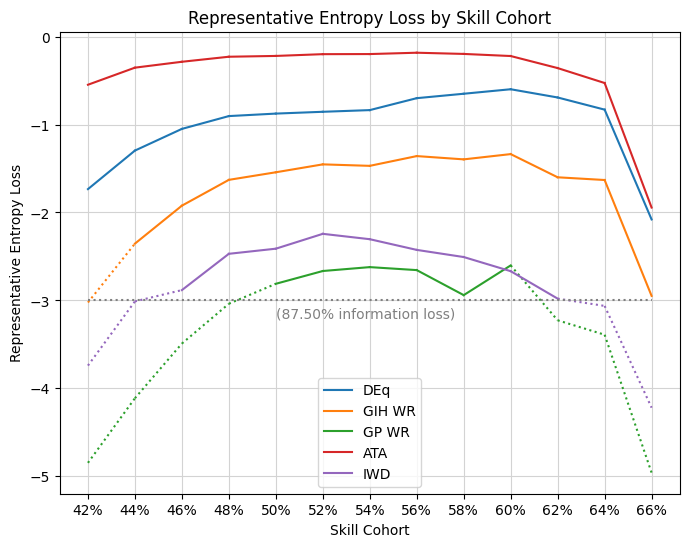

In [4]:
_ = p1strat_line_plot(
    res_all,
    mode='entropy_loss'
)
plt.show()

The metric retaining the most entropy is ATA. This makes sense. ATA describes the way that people draft, so a strategy based on ATA should
have the most general similarity to aggregate player behavior. So far so good. Next up is DEq. Not only does DEq perform the best in the win rate analysis, but it also 
gives a reasonable representation of player behavior. Furthermore, there's a trend to the shape that suggests that it is at its strongest in
modeling elite player behavior -- its maximum is in the 62% cohort, which, recall, is into elite territory and well beyond the threshold for what we 
would consider "top" drafters (and whose behavior we captured in the metrics). The observed win rate for this group is close to 65%. The consistently narrowing shape from the worst- to the best-performing cohorts tells a 
compelling story (to me anyway).

The remaining metrics have a well-established hierarchy from there. GIH WR (notably also peaking for the 62% cohort), IWD, then GP WR, with the latter two metrics barely capturing a meaningful portion of player picks.

Combining the results of the two analyses, from this sample at least, I think DEq comes out as a clear winner. We get the best of both worlds, a metric that replicates human behavior nearly as well as the actual measurement of human behavior, and delivers the best results. There's no cohort of players that clearly wouldn't benefit (as opposed to "wouldn't clearly") from using DEq to guide first picks. Let's briefly touch on the other metrics. GIH WR comes in second in the win-rate analysis, which won't surprise most of you that rely on it as a card quality metric. Frankly, I was expecting ATA to be second, because I've overrated the flaws of GIH WR and underrated how the in-game win rate signal can give durable card quality information. But GP WR and ATA also appear to be useful signals, from a quality standpoint anyway, ATA especially for top players where GIH WR is less apparently useful. Note that many of those players will already be using GIH WR to inform their choices, but not so much that the strategy has great representation in the substitution analysis. Finally IWD is just... no. Do not use IWD as a card-quality metric.


One more note on interpretation, just because 75% (or whatever) of the information is "lost" doesn't mean it's coming from neighboring cohorts. It's just a distorted view of the actual results. In general, above a value of -2 or so, it looks like only a de minimus fraction of substitute results are coming from outside of the cohort. Below the dotted line is where I would start to have serious concerns about the applicability of the result (which is why I put it there).

## Reproducible Strategies

Now, there's a major hole in this scheme. You can't make picks based on what metrics look like at the end of the format; you have to work with what you've got at the time. I felt it was important to start with the broadest analysis possible to get an idea of the stability of the analysis, and also I think there's value in a retrospective
evaluation of card quality. I picked the metrics the way I would suggest evaluating them for that purpose, so I think this suggests that DEq is the best way to look at which cards were most valuable early picks over the entire format.

Nevertheless we need to look at reproducible strategies, that is, something you could actually implement in practice. We have two passes through the data. First, the filter we use to 
calculate the metrics, and second, the set of drafts that we compare using the substitution analysis. The second set must necessarily be as large as is practical, because we saw representation issues even when using the full data set, but the first filter can represent whatever we would use in practice. So let's start with the day one metrics. That first rush we get when the 17Lands card data page fills up with numbers on that first Wednesday morning. We will use those rankings, and take the first 12 days of the format as our substitution set. Here are the results of that analysis:

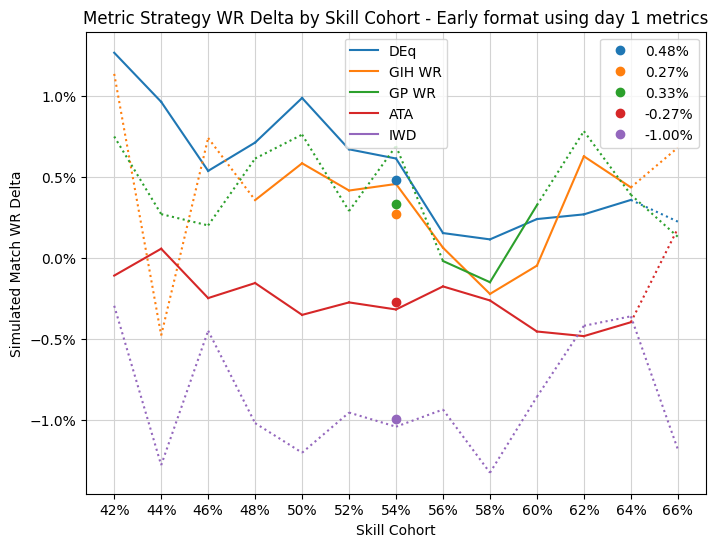

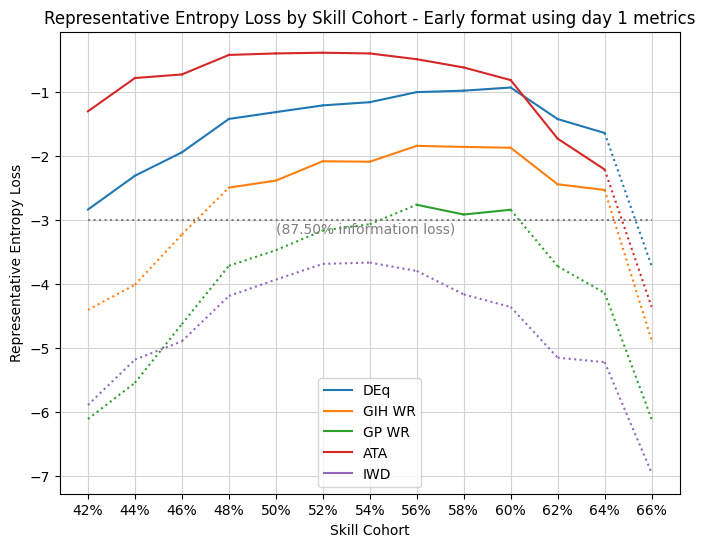

In [5]:
res_d1 = all_metrics_analysis(
    metric_filter={'format_day': 1},

    
    results_filter=EARLY_FORMAT
)
tag_d1 = "Early format using day 1 metrics"
_ = p1strat_line_plot(
    res_d1, 
    mode='wr_delta',
    title_extra=tag_d1
    
)
plt.show()
_ = p1strat_line_plot(
    res_d1,
    mode='entropy_loss',
    title_extra=tag_d1
)
plt.show()

To me, this was the most surprising and gratifying result of the bunch. Again, DEq comes out on top, although perhaps less conclusively, providing 0.48% of win rate on average across the entire data set (this time, just over a million drafts). This is from changing a single pick, and from continuing to use the day one cut for 12 days of the format! The thing that really shocked me was the gap between DEq and ATA. DEq is effectively a combination of ATA and GP WR, so for ATA to perform so poorly but this not to affect the quality of the result was a relief. I honestly had no clue how ATA or the win rate metrics would perform, so it was exciting to see a result as clear as this. The results make sense intuitively as well (though that didn't make them predictable, for me anyway). The metric is drawn from the whole player base on day 1, and ATA measures the player base's knowledge of the format -- which is nil, in this case. So it's intuitive that relying on that knowledge to make picks is a bad idea, but it's still amazing to see the stark difference between this result and the previous one where relying on ATA was comparable to GIH WR in quality.

Additionally, we see GP WR outperform GIH WR, in terms of win rate at least. While I didn't predict it, it's another intuitive result since early days of the format are all about identifying the most powerful decks and exploiting them. GP WR is the stat that will help you do that (aside from DEq, of course). We see an interesting spike for GP WR and GIH WR around 60%-62%, which could be notable, but overall we can tell the halved sample size is already taking its toll on the quality of the analysis, especially when we take a look at the entropy loss. GP WR might be pointing us towards exploitable decks, but it also seems to be recommending plenty of unpalatable choices, to the eyes of our human drafters anyway. DEq again gives the most solid representative picks, especially for the elite cohorts. In fact, for this sample we see a new effect, which is that DEq clearly overtakes ATA in terms of modeling the behavior of elite drafters. They know not to draft like the average person drafted on day one, unsuprisingly. It's also notable that GIH WR has the same general shape as DEq, although it fails to overtake ATA.

Overall, I think this is a clear call to value those early day's returns highly, and to use DEq to interpret them. For this data set, anyway, there is apparently a lot of juice to squeeze for more wins.

Next up, we'll evaluate the late format using metrics from the early format. This transition period to the stable metagame can be especially difficult for those of us relying on metrics, which can still be pointing to archetypes which have had the life squeezed out of them. Let's take a look:

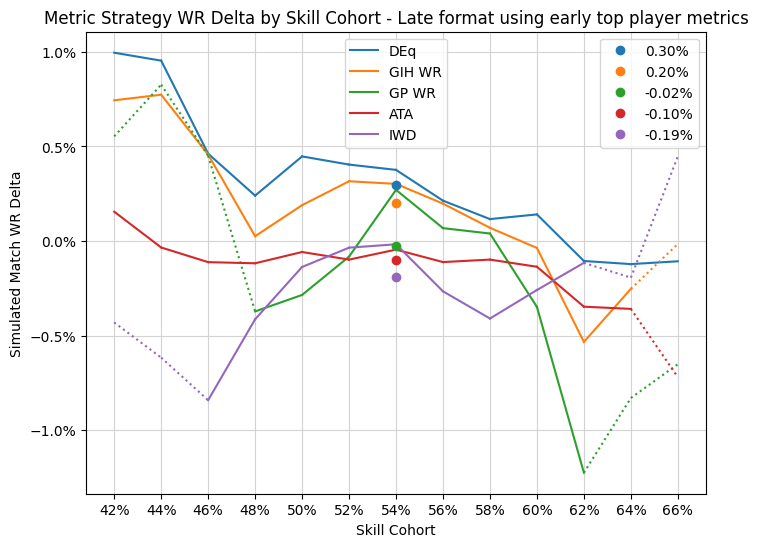

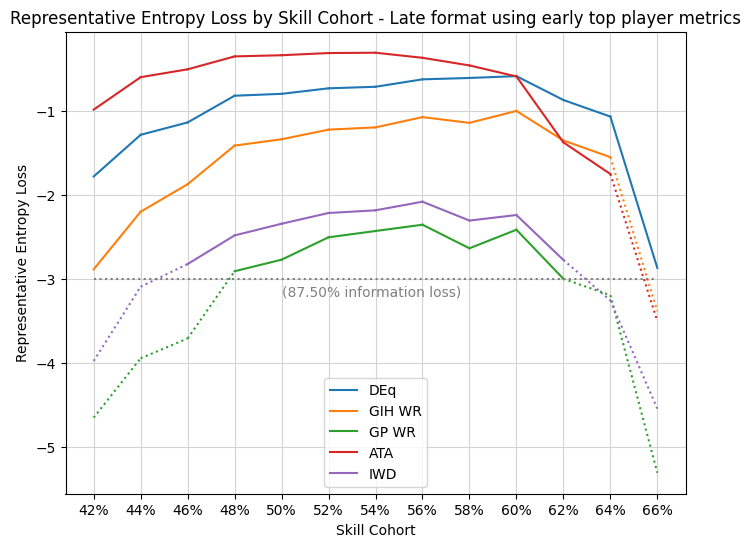

In [6]:
tag_luet = 'Late format using early top player metrics'
res_luet = all_metrics_analysis(
    metric_filter=EARLY_TOP,
    results_filter=LATE_FORMAT
)
_ = p1strat_line_plot(
    res_luet, 
    mode='wr_delta',
    title_extra=tag_luet
)
plt.show()
_ = p1strat_line_plot(
    res_luet,
    mode='entropy_loss',
    title_extra=tag_luet
)
plt.show()

Things have gotten notably more difficult. DEq, our best performing metric, only gives us 0.3% of win rate if we continue to rely on early format returns throughout the late format. GIH WR stands out from the other 17Lands metrics in this particular cut. The heuristic that it provides a measurement of a card's individual "impact" seems to explain that effect. Unlike the early format, we can't rely on knowing which are the outperforming decks, and that game data is extra valuable. More than anything else, this chart motivates me to want to integrate the game data into my model at some point in the future. On the other hand, the spike at 62% from the previous analysis has completely reversed, so I chalk that up to noise. I'd recommend looking at both metrics during this transition phase of the format, although I can't say how to use that information. We continue to see the same behavior in the entropy metric, with DEq being the standout for elite players, but GIH WR predicting behavior better than ATA as well at the top end.

Notable is that for the first time, no metrics provide an increase in win rate to elite players under the model. As the format is progressing into its mature phase, it is up to you to adjust to the metagame correctly if you want to be in the upper echelon of players. One thing I'm very interesting in looking at down the road is how to detect that card quality signal correctly from the available data during that intermediate phase.

Finally, let's look at applying the mature metrics during the late format. I've found that sometime into week four the metrics seem to stabilize, if you cut off the date fairly aggressively.

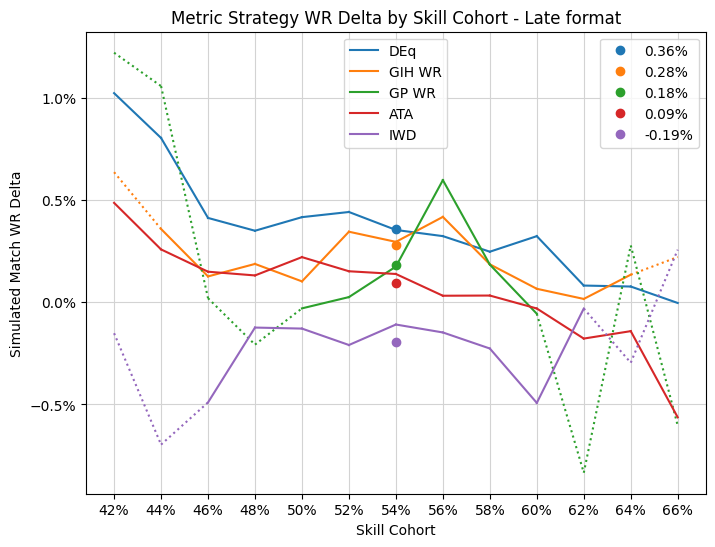

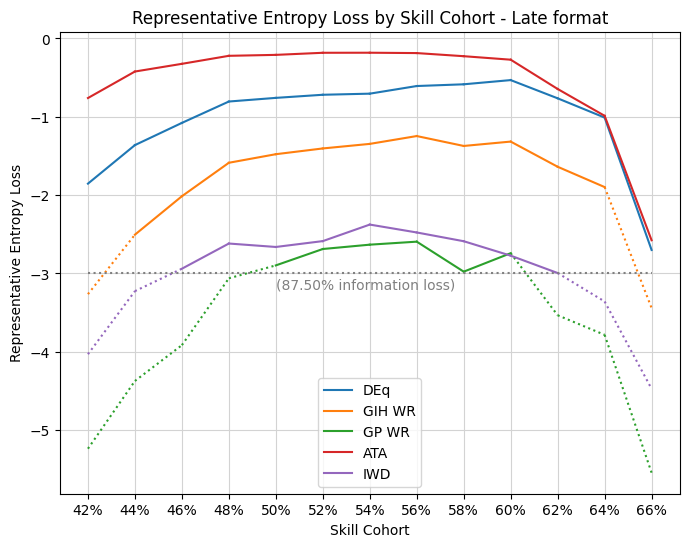

In [7]:
tag_late = 'Late format'
res_late = all_metrics_analysis(
    metric_filter=LATE_TOP,
    results_filter=LATE_FORMAT
)
_ = p1strat_line_plot(
    res_late, 
    mode='wr_delta',
    title_extra=tag_late
)
plt.show()
_ = p1strat_line_plot(
    res_late,
    mode='entropy_loss',
    title_extra=tag_late
)
plt.show()

DEq performs best again, but by the narrowest margin yet. GIH WR provides durable information, and ATA and GP WR recover somewhat in their usefulness, since the metric reflects the actual metagame, as well as the end-format knowledge of the player base. But overall, the pattern established in the previous analyses continues. DEq is the standout metric for card quality in all phases of the format. The others wax and wane in usefulness, with GIH WR being the most reliable of those, especially as the metagame changes.

## Conclusion

Well, I just presented an exhaustive suite of analyses which conveniently attempt to show that I was right all along. DEq is a good metric, the best estimate of card quality I'm aware of. Maybe you're still skeptical, which is fine. I understand there's no way for most of you to verify that my results are reliable. I hope that the experts in the community will do that and suggest improvements. I also hope you don't think that I somehow cooked the analysis to benefit my metric, or p-hacked my way to a favorable result. The analysis is my best effort at solving the problem at hand, which is evaluating the effects of drafting one card by card quality metrics using actual, representative game data. I had absolutely no way to guess how it would turn out other than my belief that I was doing things the right way. I presented every result that I ran -- I have not seen a run of this analysis where DEq did not outperform every other metric I tried (except ["DEq Base"](deq), which performs a tiny bit better, actually). Additionally,
I've been putting my own gems (but no $...) on the line using DEq since the release of OTJ and I can only recommend wholehearted that you do the same.

I promised you 1% of win rate at the outset of this article, and I think I have given you good reason to believe you can achieve that and more -- if you use DEq to pick cards, and you're smart about how to update your beliefs as the format evolves. Since you've stuck around, let me show you one more chart. This is the evolution of the win-rate delta for DEq and GIH WR over all the sets included in this analysis, using the metagame from the first version of the chart.


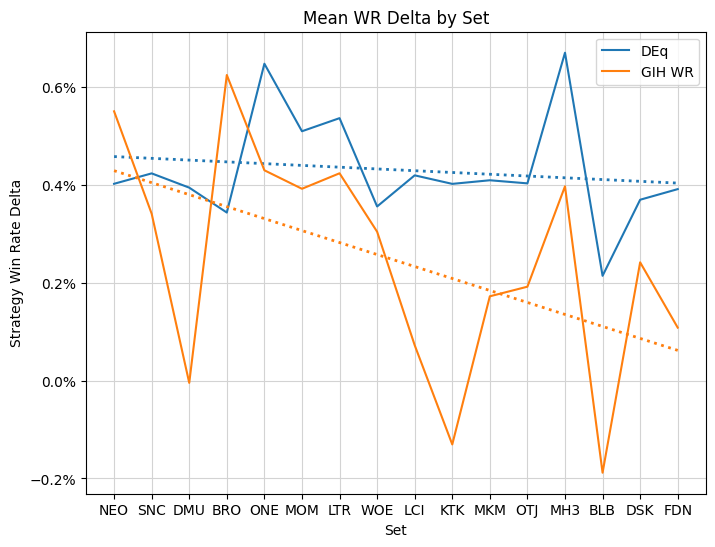

In [8]:
from deq.p1_strategy import set_by_set_results
set_by_set = set_by_set_results()
_ = set_by_set_plot(set_by_set)
plt.show()

Gather ye rosebuds. As GIH WR has become more ubiquitous, the edge to be gained has decayed, while DEq's has been durable. I wouldn't bet on it staying that way.

## Final Notes

I've spent essential all of my free time over the past four months laying the groundwork for this analysis and executing it. I skipped DSK, FDN, and PIO. I wrote the analytical python package [Spells](https://github.com/oelarnes/spells), which is designed to enable declarative, intuitive, fast, reproducible analysis of 17Lands public data, such as the above. It is documented and available on PyPI, and I indend to continue to support it. If you're interested in diving into data analytics on limited data, please go check it out. 

The code for this analysis is in a separate [deq](https://github.com/oelarnes/deq) repository, but it is available for inspection. I also intend to follow this post up with a technical description of the methods, so please keep an eye out if that's something you're interested in.

Now that I believe I've settled the question of whether I'm headed in the right direction, I intend to focus on refining and improving the metric with my next set of analysis. I also intend to move [DEq](https://docs.google.com/spreadsheets/d/1n1pfrb5q_2ICYk-vfF3Uwo8t61DJU-5T_DFe0dwk8DY/edit?usp=sharing) from Sheets to this web platform at some point down the line. Thanks for sticking around to the end.